https://ryuzyproject.tistory.com/105

1. Segmentation
Segmentation은 컴퓨터 비전에서 이미지나 영상을 픽셀 단위로 분할하여 각 영역이 무엇을 나타내는지 구분하는 기술입니다.

이는 크게 Semantic Segmentation과 Instance Segmentation으로 나뉘는데, Semantic Segmentation은 같은 종류의 객체를 동일한 클래스로 분류하는 반면, Instance Segmentation은 같은 클래스 내에서도 개별 객체를 구분합니다.

이를 통해 의료 영상 분석, 자율주행, 위성 이미지 처리 등 다양한 분야에서 정밀한 객체 인식을 수행할 수 있습니다. Segmentation 모델로는 U-Net, DeepLab, Mask R-CNN 등이 널리 사용됩니다.

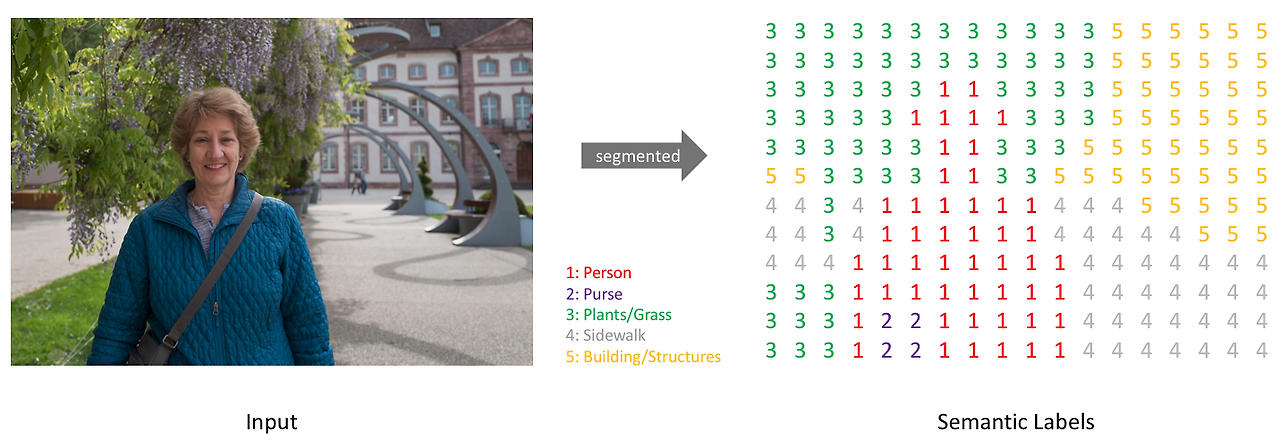

In [2]:
from pathlib import Path

s_dir = Path() / "data" / "starbucks_3_team"
s_dir.exists()

True

In [2]:
from pathlib import Path

s_dir = Path() / "data" / "starbucks_3_team"
s_dir.exists()
# from icrawler.builtin import BingImageCrawler
#
# crawler = BingImageCrawler(
#     storage={
#         "root_dir": str(s_dir)
#     }
# )
#
# crawler.crawl(
#     keyword='"Starbucks" logo',
#     filters={
#         "type": "clipart",
#         "size": "large",
#     },
#     max_num=30
# )

True

In [3]:
from ddgs import DDGS

results = DDGS().images(
    query="starbucks storefront sign",
    region="us-en",
    safesearch="moderate",
    max_results=20,
)

for result in results[:5]:
    print(result["image"])



https://static.vecteezy.com/system/resources/previews/023/440/506/large_2x/starbucks-cofee-storefront-sign-with-logo-close-up-vancouver-bc-canada-april-29-2023-free-photo.JPG
https://c8.alamy.com/comp/3D5XJ1H/starbucks-storefront-sign-on-yellow-stucco-building-with-metal-awning-and-windows-south-san-francisco-california-october-16-2025-photo-by-smith-collectiongadosipa-usa-3D5XJ1H.jpg
https://www.alamy.com/aggregator-api/download?url=https://c8.alamy.com/comp/2JWK6K8/starbucks-coffee-sign-at-storefront-starbucks-locations-serve-worldwide-hot-and-cold-drinks-all-sorts-of-halifax-nova-scotia-canada-aug-2022-2JWK6K8.jpg
https://c8.alamy.com/comp/2F5X1A5/starbucks-coffee-shop-signboard-store-front-exterior-logo-sign-brand-symbol-signage-closeup-nobody-facade-florianska-street-cracow-old-town-urba-2F5X1A5.jpg
https://www.terraformco.com/wp-content/uploads/2017/06/starbucks-storefront-5.jpg


In [4]:
print(Path("data/starbucks_dataset").resolve())

C:\LANG_CHAIN_2026\2026-05-19_KDT_lang_chain\01_class\computer_vision\18_computer_vision_opencv_lessons\data\starbucks_dataset


In [13]:
from pathlib import Path
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
import random
import shutil

import requests
from PIL import Image
import imagehash
from ddgs import DDGS


# ============================================================
# 설정
# ============================================================

# 키워드별 원본 이미지가 저장되는 위치
BASE_DIR = Path("data/starbucks_dataset")

# 최종적으로 모든 이미지를 섞어서 병합하는 위치
MERGED_DIR = Path("data/starbucks_merged")


# 카테고리별 최종적으로 얻고 싶은 이미지 개수
PER_KEYWORD = 75

# 다운로드 후보는 실패/중복을 고려해서 더 많이 검색
CANDIDATE_MULTIPLIER = 5

# 동시에 다운로드하는 Thread 수
MAX_WORKERS = 8

# 너무 작은 이미지 제거 기준
MIN_WIDTH = 200
MIN_HEIGHT = 200

# pHash distance
# 작을수록 중복 판정이 엄격함
PHASH_THRESHOLD = 2

# shuffle 재현성을 위한 seed
RANDOM_SEED = 42

# 이전 실행 결과를 지우고 새로 받을지 여부
RESET_RAW_DATA = True


HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 "
        "(KHTML, like Gecko) "
        "Chrome/152.0 Safari/537.36"
    )
}


# ============================================================
# 검색 키워드
# ============================================================
keyword_groups = {
    # "storefront": "starbucks storefront",
    # "storefront_city": "starbucks storefront city street",
    # "storefront_korea": "starbucks store korea exterior",
    #
    # "sign": "starbucks outdoor sign",
    # "sign_close": "starbucks sign close up",
    # "sign_far": "starbucks sign far away",
    # "sign_side": "starbucks sign side view",
    #
    # "night": "starbucks store at night",
    # "night_sign": "starbucks illuminated sign night",
    #
    # "cup": "starbucks cup logo",
    # "cup_table": "starbucks cup on table",
    # "cup_hand": "starbucks cup in hand",
    #
    # "window": "starbucks logo window",
    # "interior": "starbucks cafe interior logo",
    #
    # "street": "starbucks street view",
    # "mall": "starbucks mall store",
    #
    # "sticker": "starbucks sticker",
    # "keyring": "starbucks key ring logo text"
    "tumbler": "starbucks tumbler logo",
    "merchandise": "starbucks merchandise logo",
    "drive_thru": "starbucks drive thru sign",
    "paper_bag": "starbucks paper bag logo",
    "food_package": "starbucks food packaging logo",
}

# ============================================================
# 공유 상태
# ============================================================

# 전체 카테고리에서 이미 저장된 이미지들의 pHash
saved_hashes = []

# 여러 Thread가 동시에 saved_hashes / count를
# 수정하지 못하도록 보호
state_lock = Lock()


# ============================================================
# 이미지 유사도 검사
# ============================================================

def is_duplicate(current_hash):
    """
    이미 저장된 이미지와 pHash distance를 비교한다.

    return
        True  : 너무 비슷한 이미지 존재
        False : 새로운 이미지
    """

    for old_hash in saved_hashes:

        distance = current_hash - old_hash

        if distance <= PHASH_THRESHOLD:
            return True

    return False


# ============================================================
# 이미지 다운로드
# ============================================================

def fetch_image(url):
    """
    URL에서 이미지를 다운로드하고 검증한다.

    return:
        성공 -> PIL.Image
        실패 -> None
    """

    try:

        response = requests.get(
            url,
            headers=HEADERS,
            timeout=10
        )

        if response.status_code != 200:
            return None


        # 이미지가 아닌 HTML 등이 내려오는 경우 제거
        content_type = response.headers.get(
            "Content-Type",
            ""
        )

        if "image" not in content_type.lower():
            return None


        img = Image.open(
            BytesIO(response.content)
        )

        # 실제 데이터를 읽어서 깨진 이미지 확인
        img.load()


        # 너무 작은 이미지 제거
        if (
            img.width < MIN_WIDTH
            or img.height < MIN_HEIGHT
        ):
            return None


        # JPG 저장을 위해 RGB 변환
        img = img.convert("RGB")

        return img


    except Exception:
        return None


# ============================================================
# 하나의 이미지 다운로드 + 중복 확인 + 저장
# ============================================================

def download_and_save(
    url,
    category_dir,
    category_state
):
    """
    멀티스레드에서 실행되는 함수.

    네트워크 다운로드는 병렬로 처리하고,
    pHash 검사 및 파일 번호 할당은 Lock으로 보호한다.
    """

    # ----------------------------
    # 이미지 다운로드
    # ----------------------------

    img = fetch_image(url)

    if img is None:
        return None


    # ----------------------------
    # pHash 계산
    # ----------------------------

    try:
        current_hash = imagehash.phash(img)

    except Exception:
        return None


    # ----------------------------
    # 공유 데이터 접근
    # ----------------------------

    with state_lock:

        # 이미 목표 개수를 채웠으면 종료
        if category_state["count"] >= PER_KEYWORD:
            return None


        # 중복 이미지 확인
        if is_duplicate(current_hash):
            return None


        # 저장될 번호
        index = category_state["count"]

        save_path = (
            category_dir
            / f"{index:04d}.jpg"
        )


        # ----------------------------
        # 이미지 저장
        # ----------------------------

        try:

            img.save(
                save_path,
                format="JPEG",
                quality=95
            )

        except Exception:
            return None


        # 정상 저장된 이미지의 hash만 추가
        saved_hashes.append(current_hash)

        category_state["count"] += 1


    return save_path


# ============================================================
# 하나의 카테고리 이미지 수집
# ============================================================

def crawl_category(
    category,
    keyword
):

    category_dir = BASE_DIR / category

    category_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    print()
    print("=" * 70)
    print(f"카테고리 : {category}")
    print(f"검색어   : {keyword}")
    print(f"목표     : {PER_KEYWORD}장")
    print("=" * 70)


    # --------------------------------------------------------
    # 이미지 검색
    # --------------------------------------------------------

    candidate_num = (
        PER_KEYWORD
        * CANDIDATE_MULTIPLIER
    )


    try:

        results = DDGS().images(
            query=keyword,
            region="us-en",
            safesearch="moderate",
            max_results=candidate_num
        )

    except Exception as e:

        print(
            f"[검색 실패] {category}: {e}"
        )

        return


    # URL만 추출
    urls = [
        result["image"]
        for result in results
        if result.get("image")
    ]


    print(
        f"검색 후보: {len(urls)}개"
    )


    # 카테고리 내부 저장 개수
    category_state = {
        "count": 0
    }


    # --------------------------------------------------------
    # 멀티스레드 다운로드
    # --------------------------------------------------------

    with ThreadPoolExecutor(
        max_workers=MAX_WORKERS
    ) as executor:


        futures = [

            executor.submit(
                download_and_save,
                url,
                category_dir,
                category_state
            )

            for url in urls
        ]


        for future in as_completed(futures):

            try:

                save_path = future.result()

                if save_path is not None:

                    print(
                        f"[저장] {save_path}"
                    )

            except Exception as e:

                print(
                    f"[Thread 오류] {e}"
                )


    print()

    print(
        f"{category}: "
        f"{category_state['count']}장 저장 완료"
    )


# ============================================================
# 전체 이미지 수집
# ============================================================

def crawl_images():

    # 이전 실행 결과 초기화
    if RESET_RAW_DATA:

        if BASE_DIR.exists():
            shutil.rmtree(BASE_DIR)


    BASE_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


    print()
    print("#" * 70)
    print("Starbucks 이미지 수집 시작")
    print("#" * 70)


    for category, keyword in keyword_groups.items():

        crawl_category(
            category,
            keyword
        )


    print()
    print("#" * 70)
    print("이미지 수집 완료")
    print("#" * 70)


# ============================================================
# 카테고리별 이미지 개수 출력
# ============================================================

def print_dataset_info():

    print()
    print("=" * 70)
    print("카테고리별 이미지 개수")
    print("=" * 70)


    total = 0


    for category in keyword_groups:

        category_dir = (
            BASE_DIR
            / category
        )


        files = list(
            category_dir.glob("*.jpg")
        )


        count = len(files)

        total += count


        print(
            f"{category:15s}: "
            f"{count:4d}장"
        )


    print("-" * 70)

    print(
        f"{'TOTAL':15s}: "
        f"{total:4d}장"
    )


# ============================================================
# 모든 이미지 Shuffle + 병합
# ============================================================

def merge_and_shuffle():

    # 모든 하위 폴더의 JPG 가져오기
    image_paths = list(
        BASE_DIR.rglob("*.jpg")
    )


    print()
    print("=" * 70)
    print("이미지 병합")
    print("=" * 70)

    print(
        f"병합 대상: {len(image_paths)}장"
    )


    # --------------------------------------------------------
    # Shuffle
    # --------------------------------------------------------

    rng = random.Random(
        RANDOM_SEED
    )

    rng.shuffle(
        image_paths
    )


    # --------------------------------------------------------
    # 기존 merged 폴더 제거
    # --------------------------------------------------------

    if MERGED_DIR.exists():

        shutil.rmtree(
            MERGED_DIR
        )


    MERGED_DIR.mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # 새로운 이름으로 복사
    # --------------------------------------------------------

    for index, src_path in enumerate(
        image_paths,
        start=1
    ):

        dst_path = (
            MERGED_DIR
            / f"{index:06d}.jpg"
        )


        shutil.copy2(
            src_path,
            dst_path
        )


    print()
    print("병합 완료")

    print(
        f"저장 위치 : {MERGED_DIR}"
    )

    print(
        f"총 이미지 : {len(image_paths)}장"
    )


# ============================================================
# 실행
# ============================================================

def main():

    # 1.
    # 검색 + 멀티스레드 다운로드
    # crawl_images()


    # 2.
    # 데이터 개수 확인
    # print_dataset_info()


    # 3.
    # 전체 이미지 shuffle + 병합
    merge_and_shuffle()


if __name__ == "__main__":
    main()


이미지 병합
병합 대상: 700장

병합 완료
저장 위치 : data\starbucks_merged
총 이미지 : 700장
